# 🌲 Forest Cover Type Classification

**Dataset:** Covertype (UCI Machine Learning Repository)

**Goal:** Predict the **type of forest cover** (e.g., spruce/fir, lodgepole pine, aspen, etc.) based on **cartographic and environmental features** such as elevation, slope, soil type, and distance to hydrology.

**Process:**
Clean and preprocess the data, handle categorical and numerical features, and train **multi-class classification models** using **tree-based algorithms**. Evaluate model performance using accuracy, confusion matrix, and feature importance visualization.

**Tools & Libraries:**
Python | Pandas | Scikit-learn | XGBoost | Matplotlib

**Covered Topics:**
Multi-class classification · Decision Trees · Random Forest · XGBoost · Feature Engineering

**Bonus:**
Compare model performance (e.g., Random Forest vs. XGBoost) and perform **hyperparameter tuning** to optimize accuracy.

---

## 1️⃣ import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

---

## 2️⃣ Data Loading & Overview

In [2]:
df = pd.read_csv("../data/covtype.csv")
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [3]:
print('Shape:', df.shape)
df.info()
print(df.describe())

Shape: (581012, 55)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                

In [4]:
df['Cover_Type'].value_counts()

Cover_Type
2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: count, dtype: int64

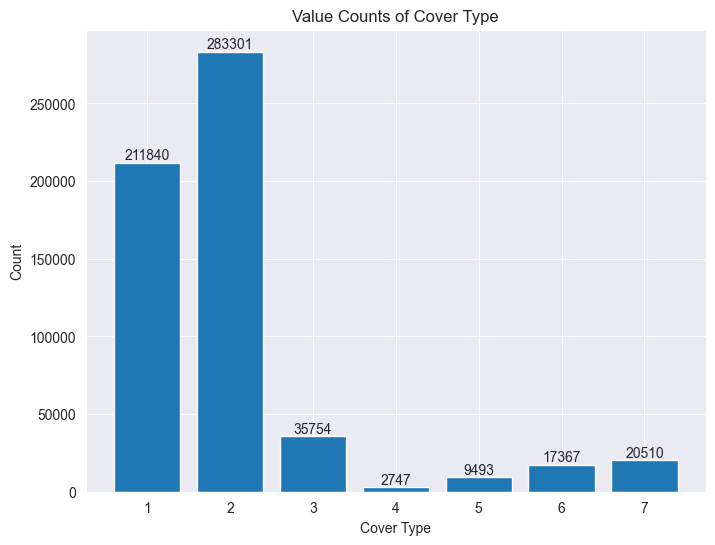

In [5]:
cover_type_count = df['Cover_Type'].value_counts().sort_index()
plt.figure(figsize=(8,6))
bars = plt.bar(x=cover_type_count.index, height=cover_type_count.values)
plt.bar_label(bars, fmt='%.0f')
plt.title("Value Counts of Cover Type")
plt.xlabel("Cover Type")
plt.ylabel("Count")
plt.show()

In [6]:
print("Missing values:", df.isna().sum().sum())
print("Duplicates:", df.duplicated().sum())

Missing values: 0
Duplicates: 0


---

## 3️⃣ Exploratory Data Analysis (EDA)

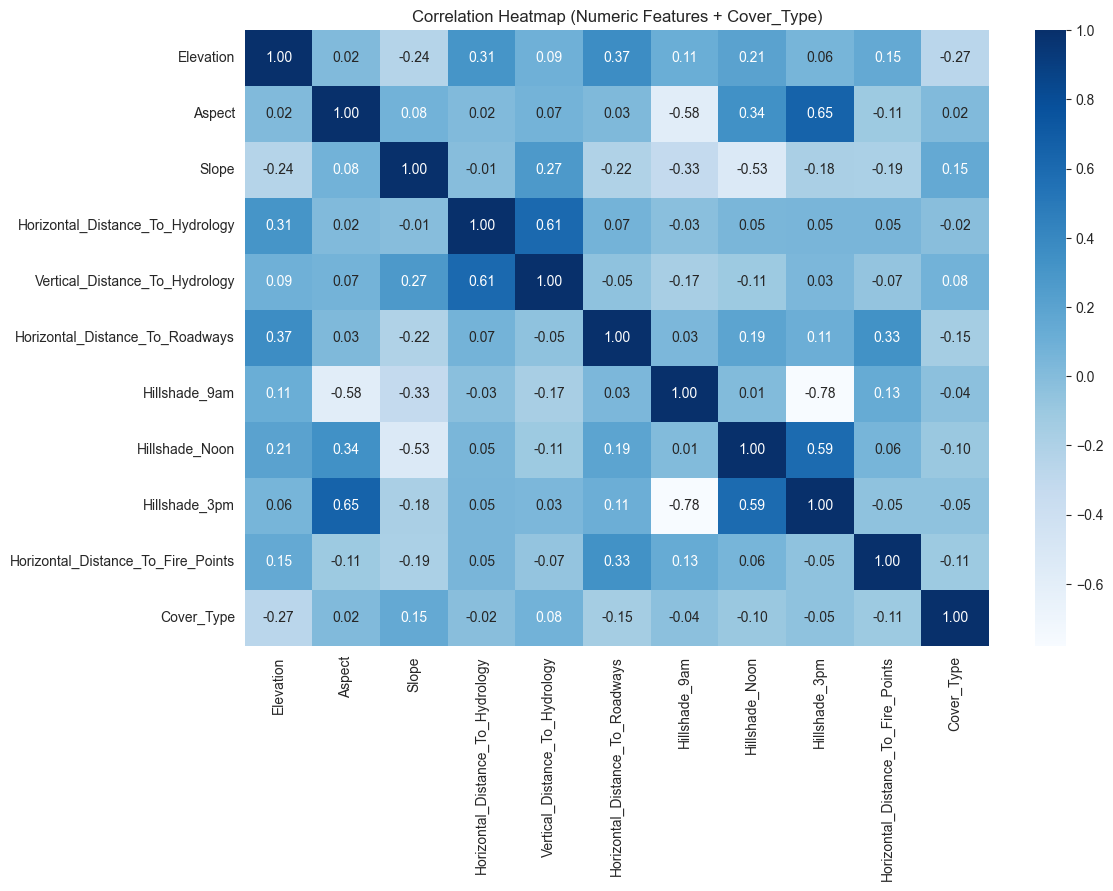

In [7]:
num_cols = df.columns[:10].tolist() + ['Cover_Type']
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features + Cover_Type)")
plt.show()

In [8]:
desc_stats = df.describe().T
desc_stats["median"] = df.median()
desc_stats["skewness"] = df.skew()
desc_stats = desc_stats[["mean", "median", "std", "min", "25%", "50%", "75%", "max", "skewness"]]
desc_stats.head(10)

,mean,median,std,min,25%,50%,75%,max,skewness
Elevation,2959.365301,2996.0,279.984734,1859.0,2809.0,2996.0,3163.0,3858.0,-0.817596
Aspect,155.656807,127.0,111.913721,0.0,58.0,127.0,260.0,360.0,0.402628
Slope,14.103704,13.0,7.488242,0.0,9.0,13.0,18.0,66.0,0.789273
Horizontal_Distance_To_Hydrology,269.428217,218.0,212.549356,0.0,108.0,218.0,384.0,1397.0,1.140437
Vertical_Distance_To_Hydrology,46.418855,30.0,58.295232,-173.0,7.0,30.0,69.0,601.0,1.790250
Horizontal_Distance_To_Roadways,2350.146611,1997.0,1559.254870,0.0,1106.0,1997.0,3328.0,7117.0,0.713679
Hillshade_9am,212.146049,218.0,26.769889,0.0,198.0,218.0,231.0,254.0,-1.181147
Hillshade_Noon,223.318716,226.0,19.768697,0.0,213.0,226.0,237.0,254.0,-1.063056
Hillshade_3pm,142.528263,143.0,38.274529,0.0,119.0,143.0,168.0,254.0,-0.277053
Horizontal_Distance_To_Fire_Points,1980.291226,1710.0,1324.195210,0.0,1024.0,1710.0,2550.0,7173.0,1.288644


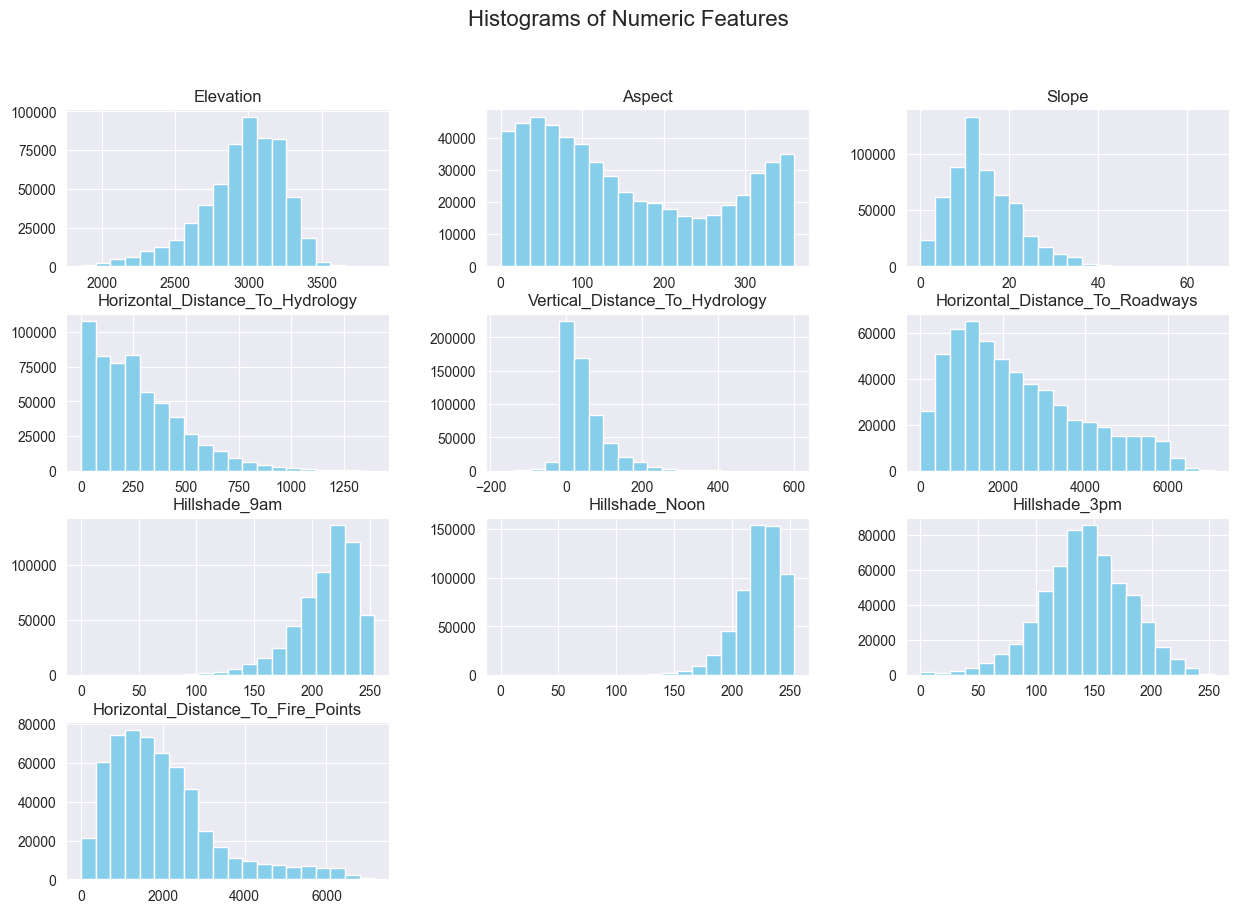

In [9]:
# Histograms
df.iloc[:, :10].hist(figsize=(15,10), bins=20, color='skyblue')
plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.show()

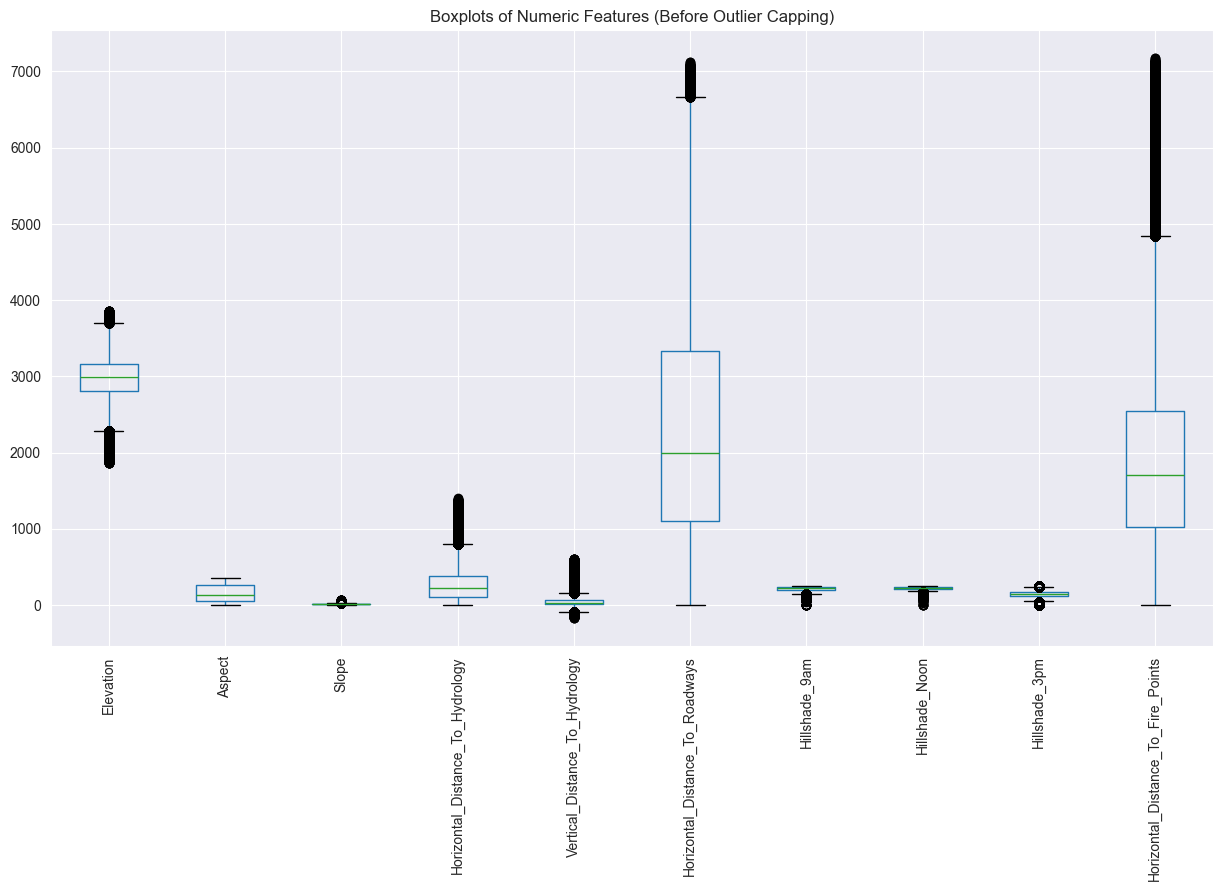

In [10]:
# Boxplots (before outlier handling)
plt.figure(figsize=(15,8))
df.iloc[:, :10].boxplot()
plt.title("Boxplots of Numeric Features (Before Outlier Capping)")
plt.xticks(rotation=90)
plt.show()

### Capping the outliers by replacing extreme values with boundary values

In [11]:
num_features = df.columns[:10]
Q1 = df[num_features].quantile(0.25)
Q3 = df[num_features].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[num_features] < (Q1 - 1.5 * IQR)) | (df[num_features] > (Q3 + 1.5 * IQR))).sum()
print("Outliers per feature:\n", outliers.sort_values(ascending=False))

# Cap outliers
for col in num_features:
    lower_bound = Q1[col] - 1.5 * IQR[col]
    upper_bound = Q3[col] + 1.5 * IQR[col]
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

Outliers per feature:
 Vertical_Distance_To_Hydrology        31463
Horizontal_Distance_To_Fire_Points    31157
Hillshade_9am                         17433
Hillshade_Noon                        15672
Elevation                             15569
Slope                                 15316
Horizontal_Distance_To_Hydrology      14557
Hillshade_3pm                          7832
Horizontal_Distance_To_Roadways         669
Aspect                                    0
dtype: int64


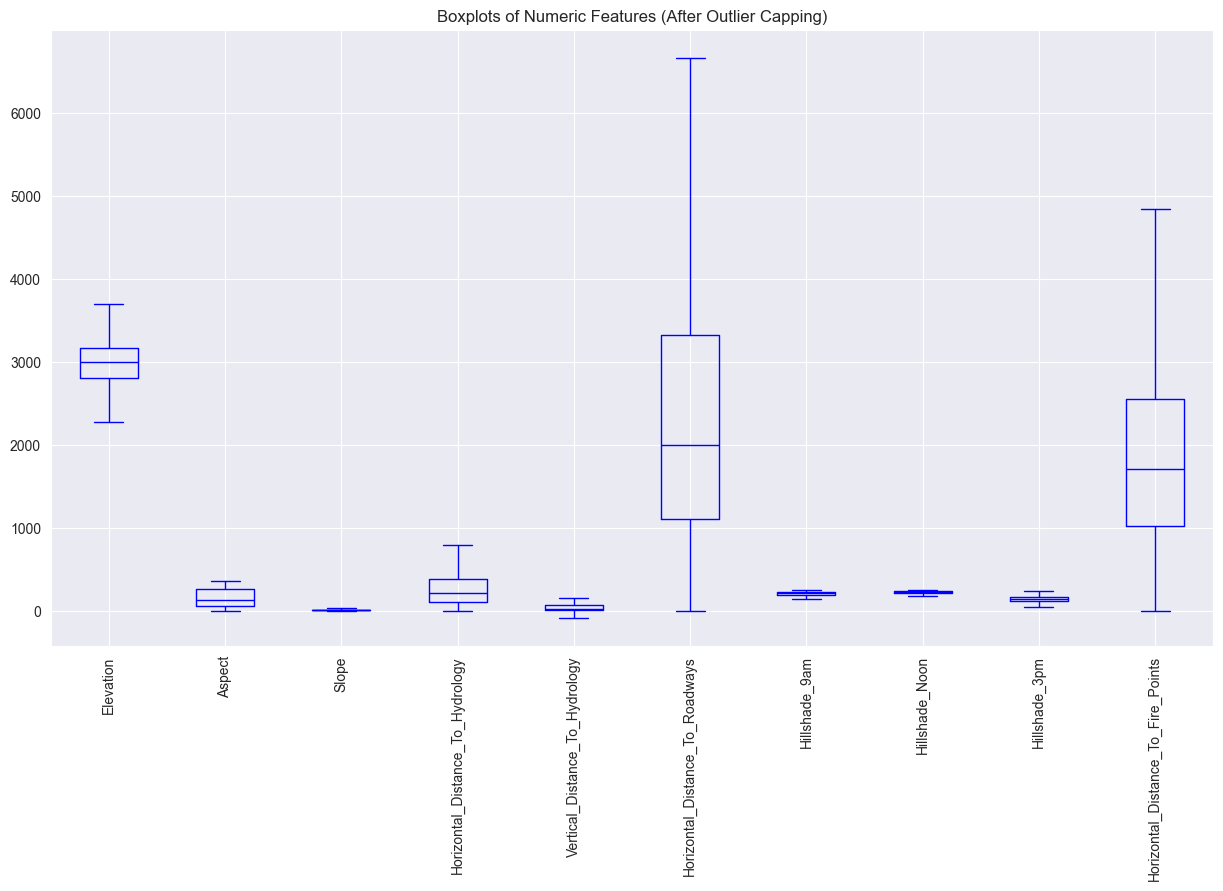

In [12]:
# Boxplots after
plt.figure(figsize=(15,8))
df[num_features].boxplot(color='blue')
plt.title("Boxplots of Numeric Features (After Outlier Capping)")
plt.xticks(rotation=90)
plt.show()

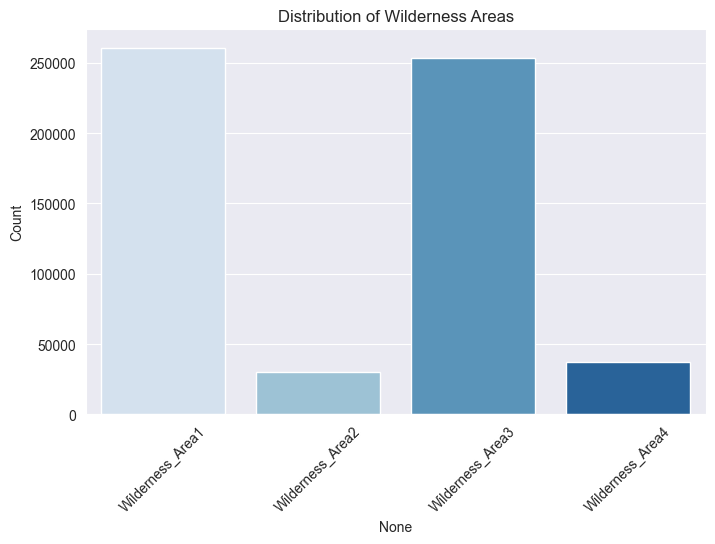

In [13]:
wilderness_counts = df[[col for col in df.columns if "Wilderness_Area" in col]].sum()
plt.figure(figsize=(8,5))
sns.barplot(x=wilderness_counts.index, y=wilderness_counts.values, palette="Blues")
plt.title("Distribution of Wilderness Areas")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

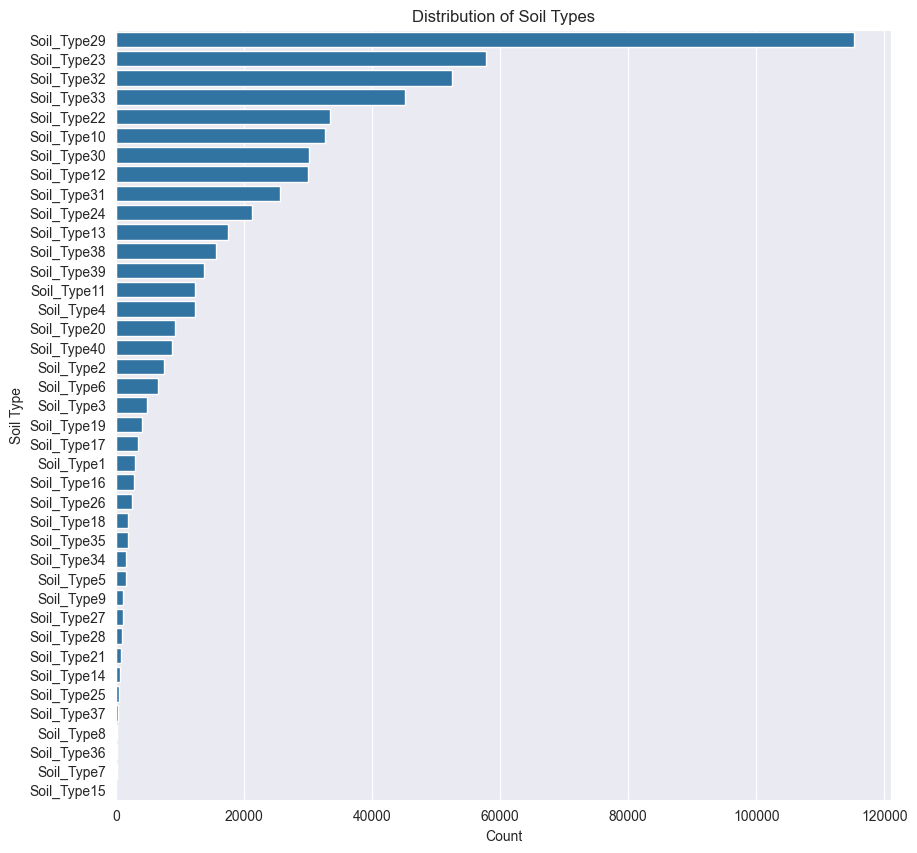

In [14]:
soil_counts = df[[col for col in df.columns if "Soil_Type" in col]].sum().sort_values(ascending=False)
plt.figure(figsize=(10,10))
sns.barplot(x=soil_counts.values, y=soil_counts.index)
plt.title("Distribution of Soil Types")
plt.xlabel("Count")
plt.ylabel("Soil Type")
plt.show()

---

### 4️⃣ Preprocessing & Feature Engineering

In [15]:
# Consolidate Soil Types (from 40 dummies to 1 integer column):
soil_cols = [col for col in df.columns if col.startswith("Soil_Type")]
df["Soil_Type"] = df[soil_cols].idxmax(axis=1).str.replace("Soil_Type", "").astype(int)
df = df.drop(columns=soil_cols)

num_cols = list(num_features) + ['Soil_Type']

df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type,Soil_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,4839.0,1,0,0,0,5,29
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,4839.0,1,0,0,0,5,29
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,4839.0,1,0,0,0,2,12
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,4839.0,1,0,0,0,2,30
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,4839.0,1,0,0,0,5,29


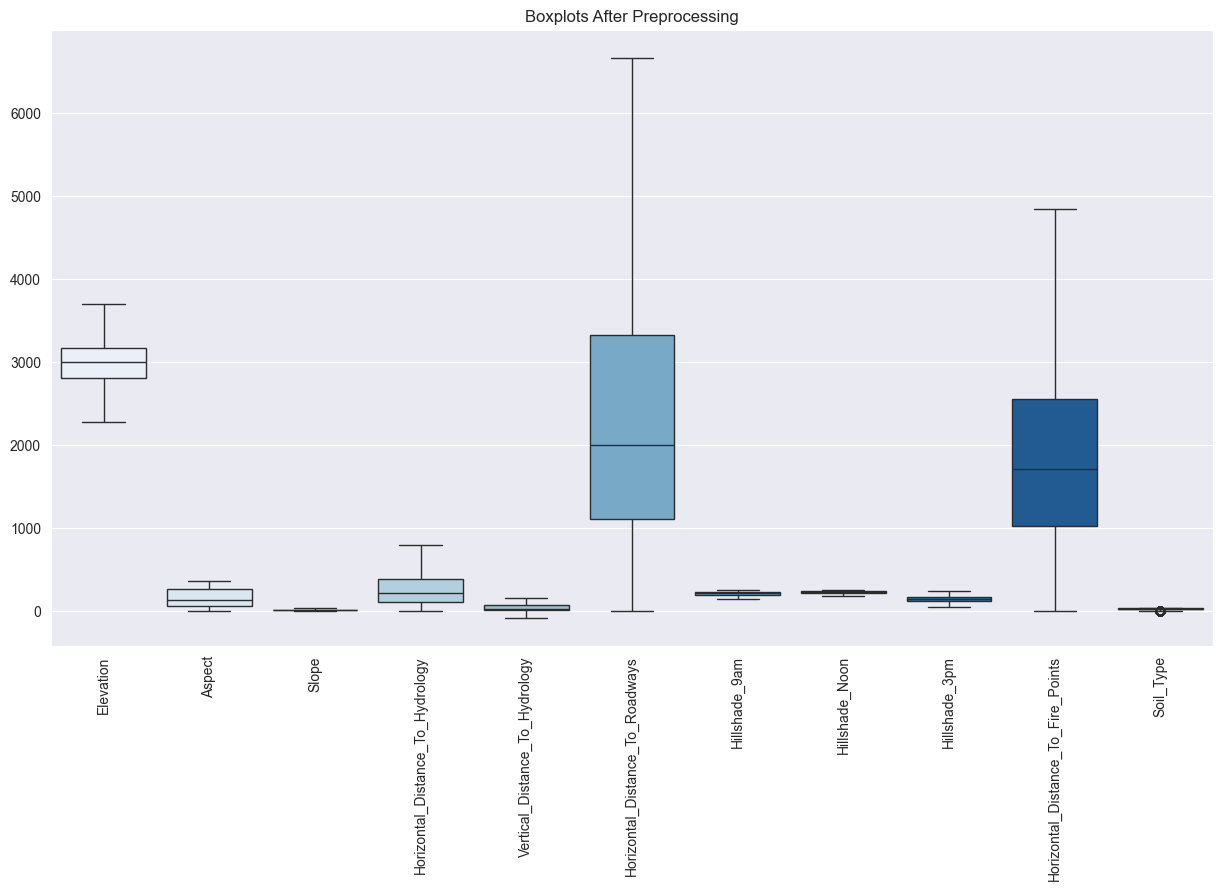

In [16]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df[num_cols], palette='Blues')  # Convert to list here
plt.title("Boxplots After Preprocessing")
plt.xticks(rotation=90)
plt.show()

---

## 5️⃣ Data Splitting & Scaling

In [17]:
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type'] - 1  # Shift to 0-6 for XGB

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

---

## 6️⃣ Model Training & Evaluation

### Decision Tree (Baseline):

In [18]:
dt = DecisionTreeClassifier(random_state=42, max_depth=20)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9183497844289734
              precision    recall  f1-score   support

           0       0.92      0.91      0.92     42368
           1       0.92      0.94      0.93     56661
           2       0.92      0.91      0.91      7151
           3       0.84      0.81      0.82       549
           4       0.81      0.71      0.76      1899
           5       0.86      0.85      0.85      3473
           6       0.95      0.93      0.94      4102

    accuracy                           0.92    116203
   macro avg       0.89      0.86      0.88    116203
weighted avg       0.92      0.92      0.92    116203



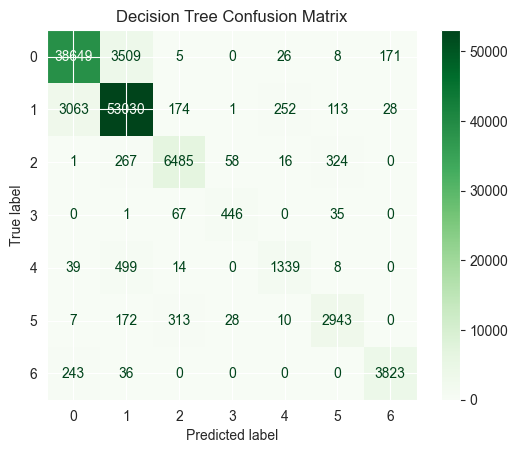

In [19]:
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt.classes_)
disp.plot(cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.show()

### Random Forest (with imbalance handling):

In [20]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.957307470547232
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     42368
           1       0.95      0.98      0.96     56661
           2       0.93      0.96      0.95      7151
           3       0.89      0.84      0.87       549
           4       0.95      0.80      0.87      1899
           5       0.93      0.88      0.90      3473
           6       0.98      0.95      0.96      4102

    accuracy                           0.96    116203
   macro avg       0.94      0.91      0.92    116203
weighted avg       0.96      0.96      0.96    116203



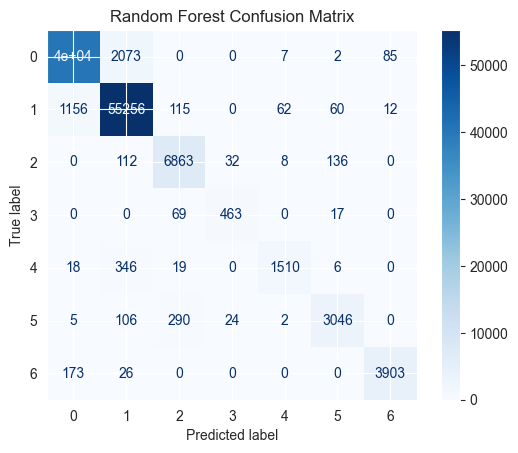

In [21]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.show()

### XGBoost:

In [22]:
xgb = XGBClassifier(n_estimators=100, random_state=42, max_depth=20, objective='multi:softmax', num_class=7)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9707408586697417
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     42368
           1       0.97      0.98      0.98     56661
           2       0.96      0.97      0.96      7151
           3       0.89      0.86      0.88       549
           4       0.94      0.90      0.92      1899
           5       0.95      0.93      0.94      3473
           6       0.97      0.97      0.97      4102

    accuracy                           0.97    116203
   macro avg       0.95      0.94      0.94    116203
weighted avg       0.97      0.97      0.97    116203



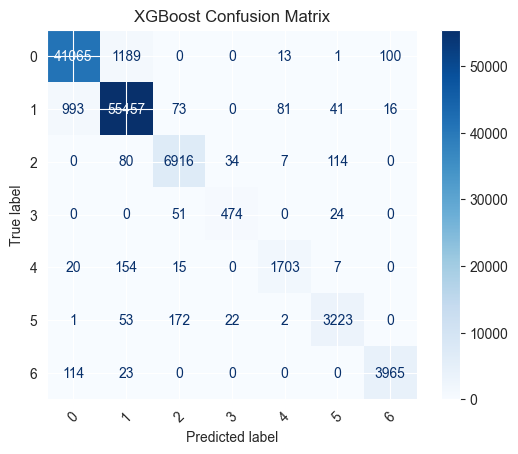

In [23]:
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("XGBoost Confusion Matrix")
plt.show()

---

## 7️⃣ Feature Importance

### Random Forest:

In [24]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

print("Top Features (RF):")
for i in range(len(X.columns)):
    print(f"{X.columns[indices[i]]}: {importances[indices[i]]:.4f}")

Top Features (RF):
Elevation: 0.2361
Soil_Type: 0.1639
Horizontal_Distance_To_Roadways: 0.1141
Horizontal_Distance_To_Fire_Points: 0.0958
Horizontal_Distance_To_Hydrology: 0.0634
Vertical_Distance_To_Hydrology: 0.0509
Hillshade_9am: 0.0509
Aspect: 0.0451
Wilderness_Area4: 0.0395
Hillshade_Noon: 0.0369
Hillshade_3pm: 0.0353
Slope: 0.0271
Wilderness_Area1: 0.0195
Wilderness_Area3: 0.0187
Wilderness_Area2: 0.0029


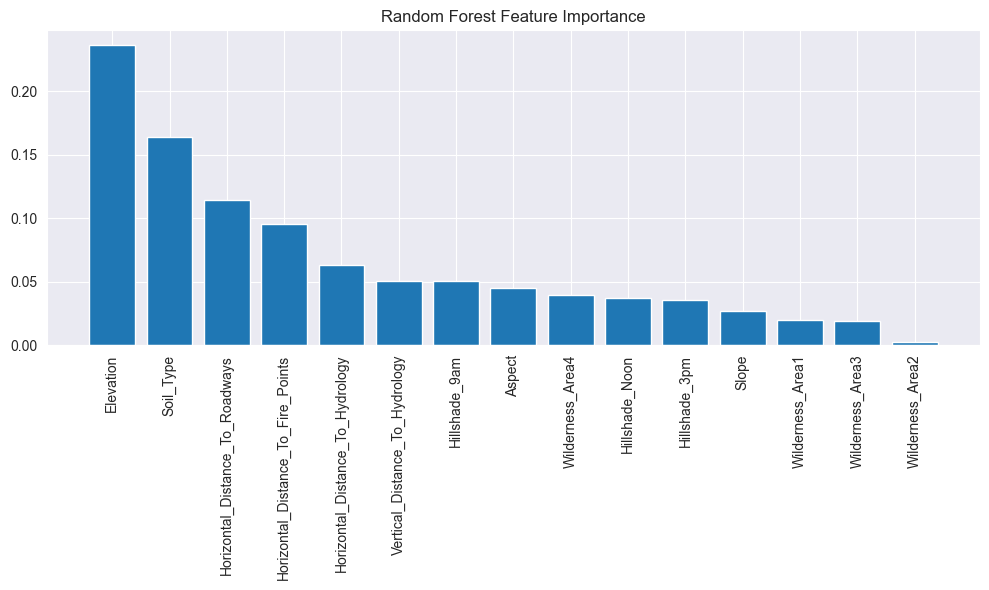

In [25]:
plt.figure(figsize=(10,6))
plt.bar(range(len(X.columns)), importances[indices])
plt.xticks(range(len(X.columns)), X.columns[indices], rotation=90)
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

### XGBoost:

In [26]:
importances = xgb.feature_importances_
indices = np.argsort(importances)[::-1]

print("Top Features (XGB):")
for i in range(len(X.columns)):
    print(f"{X.columns[indices[i]]}: {importances[indices[i]]:.4f}")

Top Features (XGB):
Wilderness_Area4: 0.2708
Soil_Type: 0.1761
Wilderness_Area2: 0.1119
Wilderness_Area3: 0.1066
Elevation: 0.0868
Wilderness_Area1: 0.0852
Horizontal_Distance_To_Roadways: 0.0293
Horizontal_Distance_To_Fire_Points: 0.0288
Horizontal_Distance_To_Hydrology: 0.0199
Hillshade_Noon: 0.0168
Hillshade_9am: 0.0167
Vertical_Distance_To_Hydrology: 0.0152
Aspect: 0.0125
Slope: 0.0121
Hillshade_3pm: 0.0114


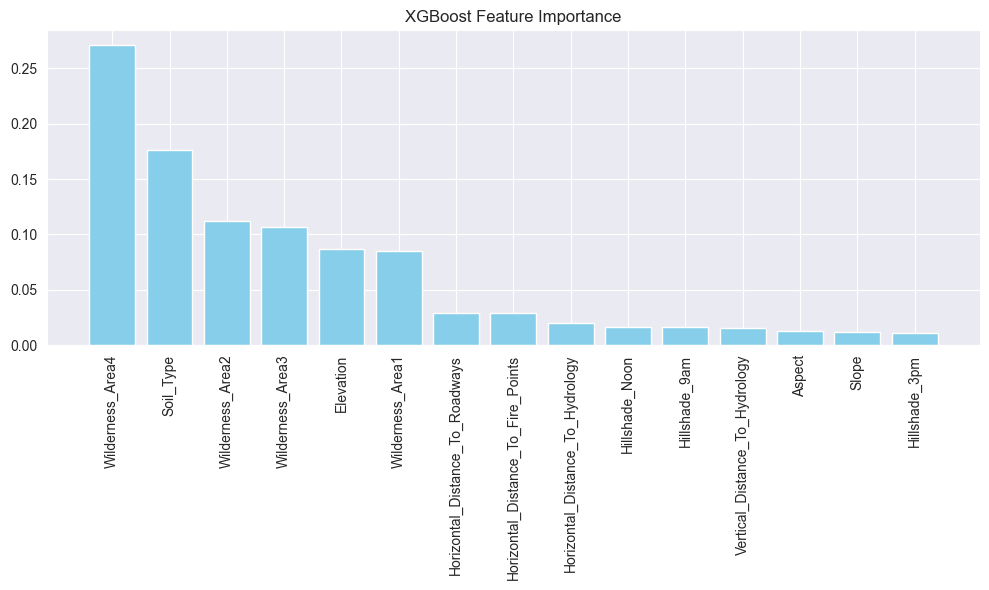

In [27]:
plt.figure(figsize=(10,6))
plt.bar(range(len(X.columns)), importances[indices], color='skyblue')
plt.xticks(range(len(X.columns)), X.columns[indices], rotation=90)
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

---

## 8️⃣ Model Comparison

In [28]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})
print(results)

           Model  Accuracy
0  Decision Tree  0.918350
1  Random Forest  0.957307
2        XGBoost  0.970741


---